In [155]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, root_mean_squared_error, r2_score

import lightgbm as lgb
import optuna
from sklearn.metrics import root_mean_squared_error, r2_score

from scipy.stats import randint

import matplotlib.pyplot as plt

In [156]:
df = pd.read_csv("../dataset_llm_fs_top60_+2.csv")
df = df.sort_values("fecha")

## Pre-procesamiento

In [157]:
df = df.sort_values("fecha")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

In [158]:
# quedarnos con el periodo para el que tenemos las variables del LLM

df = df.loc[(df["fecha"] >= "2025-01-01") & (df["fecha"] <= "2025-04-30")].copy()

In [159]:
df["fecha"].describe()

count                               77
mean     2025-03-01 19:19:28.831168768
min                2025-01-06 00:00:00
25%                2025-01-31 00:00:00
50%                2025-02-27 00:00:00
75%                2025-03-31 00:00:00
max                2025-04-30 00:00:00
Name: fecha, dtype: object

In [160]:
df = df.rename(columns={
    "merval_apertura_+2": "merval",
})

In [161]:
# Asegurarnos que no quedo ninguna fila con NA en la variable a predecir

print(df.loc[df['merval'].isna()].shape[0])

df = df.loc[df['merval'].notna()]

0


In [162]:
# chequeo de cuantos NAs tenemos en cada columna
pd.DataFrame(
    {'df (N)': df.isna().sum(),
    'df (%)': round(df.isna().sum()/df.shape[0]*100,1)}
)


,df (N),df (%)
fecha,0,0.0
sector_Agropecuario_sum_true,0,0.0
badlar_ma_5,0,0.0
emae_tendencia_ciclo_lag2,0,0.0
merval_cierre_std20,0,0.0
...,...,...
act_administracion_de_donald_trump_mean_lag1,0,0.0
impacto_commodities_mean_lag1,0,0.0
emp_la nacion_mean_lag3,0,0.0
tipo_evento_otro_prop_true,0,0.0


In [163]:
# Eliminar filas con NaN creadas por los lags (las primeras 5 si usamos hasta lags de 5 dias)
df = df.dropna().copy()

In [164]:
y = df["merval"]
# X = df.drop(columns=["merval"]) # no estoy del todo seguro si tenemos que eliminar fecha
X = df.drop(columns=["merval","fecha"]) # no estoy del todo seguro si tenemos que eliminar fecha o si la convertimos a numerica

## Train-Test Split

In [165]:
train_size = int(len(df) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

(61, 60)
(16, 60)


## Funcion objetivo para Optuna y Cross-Validation

In [166]:
max_lag = 5 # por el moving average 5

In [167]:
def objective(trial):
    # Espacios de búsqueda ajustados para ~63 filas de entrenamiento y 60 features
    params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting_type": "gbdt",
        "verbosity": -1,
        "random_state": 42,

        # Aprendizaje: mayor learning rate con pocos datos para evitar sobreajuste
        "learning_rate": trial.suggest_float("learning_rate", 0.05, 0.3, log=True),

        # Complejidad del árbol: REDUCIDA para evitar overfitting
        "num_leaves": trial.suggest_int("num_leaves", 5, 15),  # Mucho más simple
        "max_depth": trial.suggest_int("max_depth", 2, 4),  # Árboles poco profundos

        # Mínimos ajustados a dataset pequeño
        "min_child_samples": trial.suggest_int("min_child_samples", 3, 10),  # Menor con pocos datos

        # Regularizaciones L1/L2 - MÁS FUERTES para evitar overfitting
        "lambda_l1": trial.suggest_float("lambda_l1", 0.1, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 0.1, 20.0, log=True),

        # min_split_gain más alto para evitar splits innecesarios
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 2.0),

        # Submuestreo: menos agresivo con pocos datos
        "subsample": trial.suggest_float("subsample", 0.7, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 0.9),  # Feature sampling importante

        # MENOS árboles con dataset pequeño
        "n_estimators": trial.suggest_int("n_estimators", 20, 150),
        "n_jobs": -1,
    }

    # --------- Ajustes dependientes (evitan configuraciones inválidas) ---------
    eff = params.copy()

    # Alinear num_leaves con max_depth: num_leaves <= 2**max_depth cuando max_depth>0
    if eff["max_depth"] > 0:
        eff["num_leaves"] = min(eff["num_leaves"], 2 ** eff["max_depth"])

    # Activar frecuencia de bagging si hay subsample<1
    if eff["subsample"] < 1.0:
        eff["subsample_freq"] = 1

    # --------------------------------------------------------------------------

    # Cross validation con MENOS splits para dataset pequeño
    n_splits = 3  # Solo 3 folds con 63 filas
    test_size = 8  # ~2 semanas de validación
    tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size, gap=max_lag)

    rmses = []
    for tr_idx, va_idx in tscv.split(X_train):
        X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

        model = lgb.LGBMRegressor(**eff)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_va, y_va)],
            eval_metric="rmse",
            callbacks=[lgb.early_stopping(stopping_rounds=20, verbose=False)]  # Menos rounds
        )

        # Predicción usando los árboles óptimos según early stopping
        preds = model.predict(X_va, num_iteration=model.best_iteration_)
        rmse = mean_squared_error(y_va, preds, squared=False)
        rmses.append(rmse)

    return float(np.mean(rmses))

In [168]:
study = optuna.create_study(direction="minimize", study_name="lgbm_merval")
study.optimize(objective, n_trials=30, show_progress_bar=True)  # Reducido de 50 a 30 trials

print("Mejores hiperparámetros:", study.best_params)
print("Mejor RMSE CV promedio:", study.best_value)

[I 2025-11-15 18:03:54,230] A new study created in memory with name: lgbm_merval


  0%|          | 0/30 [00:00<?, ?it/s]

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 18:03:54,303] Trial 0 finished with value: 126800.04833460339 and parameters: {'learning_rate': 0.07984441269002286, 'num_leaves': 8, 'max_depth': 4, 'min_child_samples': 6, 'lambda_l1': 2.7525403696752853, 'lambda_l2': 4.621937336792377, 'min_split_gain': 1.386894357497724, 'subsample': 0.7765543920966558, 'colsample_bytree': 0.6758343008955456, 'n_estimators': 108}. Best is trial 0 with value: 126800.04833460339.
[I 2025-11-15 18:03:54,347] Trial 1 finished with value: 149443.28370351958 and parameters: {'learning_rate': 0.1835475996782951, 'num_leaves': 7, 'max_depth': 2, 'min_child_samples': 10, 'lambda_l1': 4.349806471526382, 'lambda_l2': 7.703249767246676, 'min_split_gain': 0.9741726772981762, 'subsample': 0.7555345731063176, 'colsample_bytree': 0.8875217530394122, 'n_estimators': 42}. Best is trial 0 with value: 126800.04833460339.
[I 2025-11-15 18:03:54,382] Trial 2 finished with value: 125022.86106823421 and parameters: {'learning_rate': 0.11157928731784805, 'num

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

...

[I 2025-11-15 18:03:56,048] Trial 24 finished with value: 125344.94162275619 and parameters: {'learning_rate': 0.12364020497517814, 'num_leaves': 14, 'max_depth': 3, 'min_child_samples': 5, 'lambda_l1': 0.2940132273582779, 'lambda_l2': 0.16537917406598637, 'min_split_gain': 0.3926676015164919, 'subsample': 0.8274919382758228, 'colsample_bytree': 0.6516478195001173, 'n_estimators': 114}. Best is trial 21 with value: 112504.1536957551.
[I 2025-11-15 18:03:56,159] Trial 25 finished with value: 116312.11136883276 and parameters: {'learning_rate': 0.1983906646012157, 'num_leaves': 12, 'max_depth': 3, 'min_child_samples': 7, 'lambda_l1': 0.5262664426684562, 'lambda_l2': 0.28317987337081574, 'min_split_gain': 0.14786381003787386, 'subsample': 0.801044681467171, 'colsample_bytree': 0.7107685686079698, 'n_estimators': 95}. Best is trial 21 with value: 112504.1536957551.


c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarnin

[I 2025-11-15 18:03:56,289] Trial 26 finished with value: 116560.40742903111 and parameters: {'learning_rate': 0.18731588136975053, 'num_leaves': 12, 'max_depth': 3, 'min_child_samples': 6, 'lambda_l1': 0.4575650207771543, 'lambda_l2': 0.5371188372230332, 'min_split_gain': 0.8410464652439649, 'subsample': 0.771674425010327, 'colsample_bytree': 0.7293911657475743, 'n_estimators': 119}. Best is trial 21 with value: 112504.1536957551.
[I 2025-11-15 18:03:56,389] Trial 27 finished with value: 137216.92706824455 and parameters: {'learning_rate': 0.17218659167167952, 'num_leaves': 12, 'max_depth': 3, 'min_child_samples': 6, 'lambda_l1': 0.47572315815021193, 'lambda_l2': 1.2410188332946595, 'min_split_gain': 0.7971428001243949, 'subsample': 0.7630835371670428, 'colsample_bytree': 0.7344981052000981, 'n_estimators': 100}. Best is trial 21 with value: 112504.1536957551.
[I 2025-11-15 18:03:56,483] Trial 28 finished with value: 127948.21415125886 and parameters: {'learning_rate': 0.1439300875851

c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(
c:\Users\eaneg\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


[I 2025-11-15 18:03:56,587] Trial 29 finished with value: 130727.14239233179 and parameters: {'learning_rate': 0.12877237382254875, 'num_leaves': 12, 'max_depth': 2, 'min_child_samples': 6, 'lambda_l1': 3.1779552428752016, 'lambda_l2': 3.2544728170081267, 'min_split_gain': 0.6397212064096909, 'subsample': 0.7812597493362162, 'colsample_bytree': 0.7101424493278522, 'n_estimators': 113}. Best is trial 21 with value: 112504.1536957551.
Mejores hiperparámetros: {'learning_rate': 0.21708181308719232, 'num_leaves': 14, 'max_depth': 3, 'min_child_samples': 5, 'lambda_l1': 0.21303996641101838, 'lambda_l2': 0.15833693931284262, 'min_split_gain': 0.4519626435953512, 'subsample': 0.8219498025114599, 'colsample_bytree': 0.6058078298566132, 'n_estimators': 129}
Mejor RMSE CV promedio: 112504.1536957551


In [169]:
study.best_params

{'learning_rate': 0.21708181308719232,
 'num_leaves': 14,
 'max_depth': 3,
 'min_child_samples': 5,
 'lambda_l1': 0.21303996641101838,
 'lambda_l2': 0.15833693931284262,
 'min_split_gain': 0.4519626435953512,
 'subsample': 0.8219498025114599,
 'colsample_bytree': 0.6058078298566132,
 'n_estimators': 129}

In [170]:
best_params = study.best_params
best_model = lgb.LGBMRegressor(**best_params)
best_model.fit(X_train, y_train)

[LightGBM] [Warning] lambda_l1 is set=0.21303996641101838, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.21303996641101838
[LightGBM] [Warning] lambda_l2 is set=0.15833693931284262, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.15833693931284262
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] lambda_l1 is set=0.21303996641101838, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.21303996641101838
[LightGBM] [Warning] lambda_l2 is set=0.15833693931284262, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.15833693931284262
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000109 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1163
[LightGBM] [Info] Number of data points in the train set: 61, number of used features: 60
[LightGBM] [Info] Start training from score 2424870.659836
[LightGBM] [Warning] No further s

LGBMRegressor(colsample_bytree=0.6058078298566132,
              lambda_l1=0.21303996641101838, lambda_l2=0.15833693931284262,
              learning_rate=0.21708181308719232, max_depth=3,
              min_child_samples=5, min_split_gain=0.4519626435953512,
              n_estimators=129, num_leaves=14, subsample=0.8219498025114599)

## Test

In [171]:
y_pred = best_model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Holdout RMSE: {rmse:.4f}")
print(f"Holdout R²:   {r2:.4f}")


[LightGBM] [Warning] lambda_l1 is set=0.21303996641101838, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.21303996641101838
[LightGBM] [Warning] lambda_l2 is set=0.15833693931284262, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.15833693931284262
Holdout RMSE: 193807.6449
Holdout R²:   -4.1589


In [172]:
# Agregamos las predicciones al dataframe original (solo para las filas de test)
df.loc[y_test.index, "pred_merval"] = y_pred

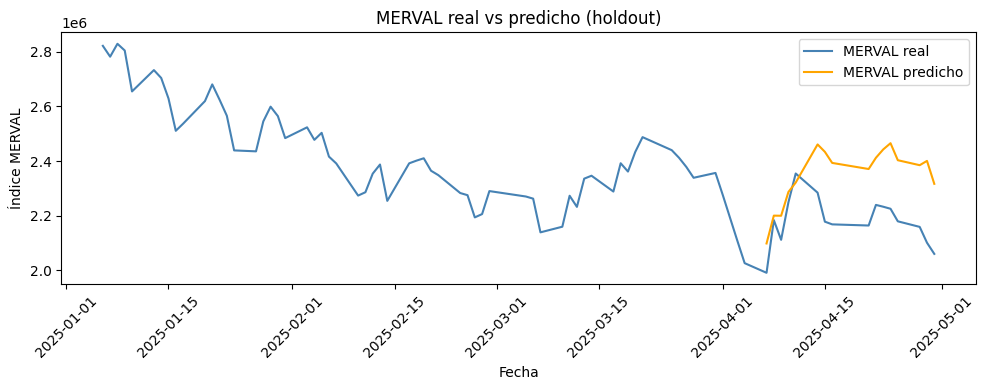

In [173]:
import matplotlib.dates as mdates

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df["fecha"], df["merval"], label="MERVAL real", color="steelblue")
ax.plot(df["fecha"], df["pred_merval"], label="MERVAL predicho", color="orange")

ax.set_title("MERVAL real vs predicho (holdout)")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


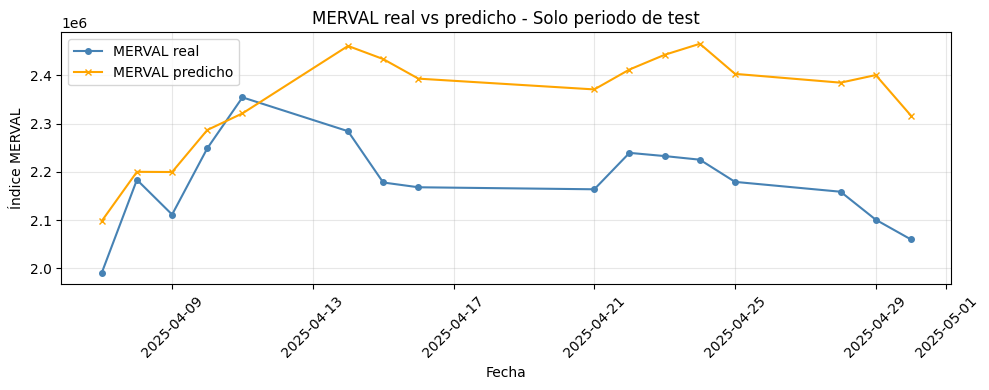

In [174]:
# Gráfico detallado solo para el periodo de test
df_test = df.loc[y_test.index]

fig, ax = plt.subplots(figsize=(10,4))
ax.plot(df_test["fecha"], df_test["merval"], label="MERVAL real", color="steelblue", marker='o', markersize=4)
ax.plot(df_test["fecha"], df_test["pred_merval"], label="MERVAL predicho", color="orange", marker='x', markersize=4)

ax.set_title("MERVAL real vs predicho - Solo periodo de test")
ax.set_xlabel("Fecha")
ax.set_ylabel("Índice MERVAL")
ax.legend()

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
ax.xaxis.set_major_locator(mdates.AutoDateLocator())
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

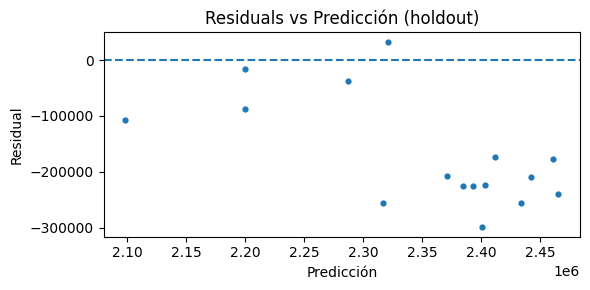

In [175]:
res = y_test - y_pred
plt.figure(figsize=(6,3))
plt.scatter(y_pred, res, s=12)
plt.axhline(0, ls="--")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.title("Residuals vs Predicción (holdout)")
plt.tight_layout(); plt.show()


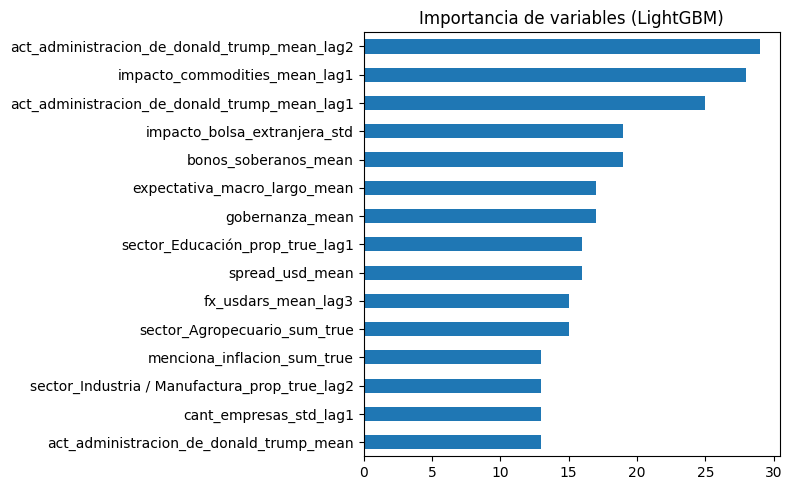

In [176]:
imp = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=True)
imp.tail(15).plot(kind="barh", figsize=(8,5), title="Importancia de variables (LightGBM)")
plt.tight_layout()
plt.show()
